In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_data(num_samples):
    X = np.random.randn(num_samples, 1) * 10
    y = 3 * X + 7 + np.random.randn(num_samples, 1)
    return X, y

In [3]:
X, y = generate_data(50)

In [4]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

In [20]:
class MiniBatchGD:
    def __init__(self, parameters, epochs = 100, lr = 0.01, minibatch_size = 10, print_on_step = None):
        self.n_epochs = epochs
        self.lr = lr
        self.theta_ = parameters
        self.minibatch_size = minibatch_size

        self.print_on_step = print_on_step

        self.loss_history = []
    def optimize(self, X, y):
        n_points, n_features = X.shape
        X = np.c_[np.ones((n_points,1)), X]
        for epoch in range(self.n_epochs):
            idx = np.random.randint(n_points)
            Xi = X[idx:idx+self.minibatch_size]
            yi = y[idx:idx+self.minibatch_size]

            # calculate prediction
            y_pred = np.dot(Xi,self.theta_)

            # calculate loss
            loss = compute_loss(yi, y_pred)
            
            # calculate gradient
            error = yi - y_pred
            gradient = - (2/n_points) * np.dot(Xi.T, error)

            # weight update
            self.theta_ -= self.lr * gradient

            if self.print_on_step:
                if (epoch+1)%self.print_on_step == 0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")
            self.loss_history.append(loss)



In [21]:
theta_ = np.random.randn(X.shape[1]+1,1)

In [22]:
minibatch_gd = MiniBatchGD(parameters = theta_, epochs = 1000, lr = 0.01, minibatch_size = 5, print_on_step = 10)

In [23]:
minibatch_gd.optimize(X,y)

Epoch: 9, Loss: 47.2449
Epoch: 19, Loss: 41.6448
Epoch: 29, Loss: 62.2638
Epoch: 39, Loss: 48.2893
Epoch: 49, Loss: 35.9984
Epoch: 59, Loss: 31.3371
Epoch: 69, Loss: 27.4585
Epoch: 79, Loss: 35.5141
Epoch: 89, Loss: 28.7342
Epoch: 99, Loss: 42.6991
Epoch: 109, Loss: 47.9287
Epoch: 119, Loss: 49.1435
Epoch: 129, Loss: 32.3417
Epoch: 139, Loss: 19.4511
Epoch: 149, Loss: 41.4502
Epoch: 159, Loss: 27.0515
Epoch: 169, Loss: 35.6127
Epoch: 179, Loss: 28.0029
Epoch: 189, Loss: 21.8997
Epoch: 199, Loss: 22.9712
Epoch: 209, Loss: 28.4452
Epoch: 219, Loss: 31.8988
Epoch: 229, Loss: 16.8848
Epoch: 239, Loss: 27.7124
Epoch: 249, Loss: 15.6534
Epoch: 259, Loss: 13.6102
Epoch: 269, Loss: 13.2692
Epoch: 279, Loss: 14.1214
Epoch: 289, Loss: 19.4812
Epoch: 299, Loss: 16.4502
Epoch: 309, Loss: 21.7609
Epoch: 319, Loss: 10.7996
Epoch: 329, Loss: 10.1111
Epoch: 339, Loss: 20.7810
Epoch: 349, Loss: 16.9868
Epoch: 359, Loss: 18.6148
Epoch: 369, Loss: 8.6210
Epoch: 379, Loss: 9.6150
Epoch: 389, Loss: 16.0355

Final Parameters using Minibatch GD: m = 3.0222, c = 6.2637


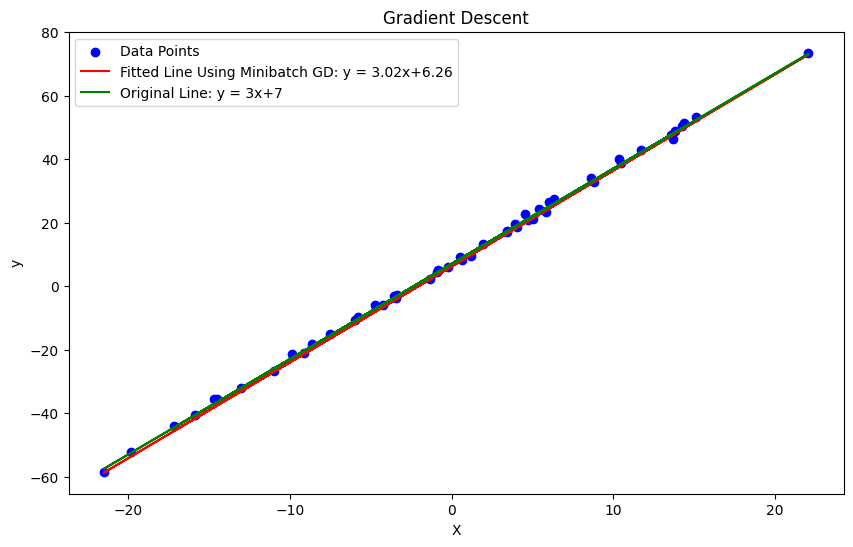

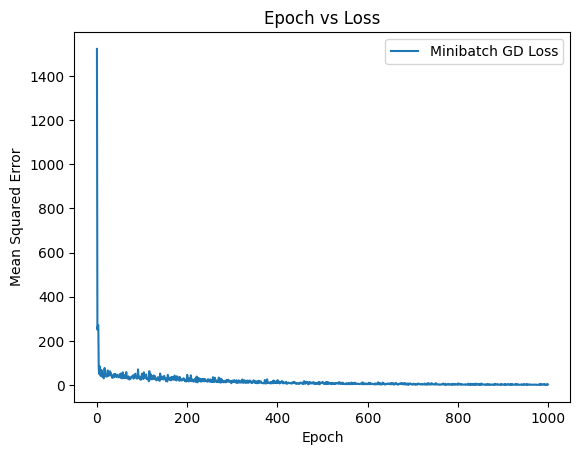

In [24]:
c,m = minibatch_gd.theta_
print(f"Final Parameters using Minibatch GD: m = {m[0]:.4f}, c = {c[0]:.4f}")
plt.figure(figsize=(10,6))
plt.scatter(X,y,label='Data Points',color='blue')
plt.plot(X,np.c_[np.ones((X.shape[0],1)),X].dot(minibatch_gd.theta_),label=f"Fitted Line Using Minibatch GD: y = {m[0]:.2f}x+{c[0]:.2f}",color='red')
plt.plot(X,3*X+7,label=f"Original Line: y = {3}x+{7}",color='green')
plt.title("Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

plt.plot(minibatch_gd.loss_history,label="Minibatch GD Loss")
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()